# B-6511502A — AutoML: Melhor Modelo

Visualiza os resultados da rodada de AutoML para detecção de anomalias na bomba B-6511502A.

- **Falha:** 15/Mai/2023 — Quebra das lâminas do acoplamento
- **14 sensores:** vibração radial em 4 mancais (2 direções cada), temperatura, corrente, pressão
- `prefailure_days=15`, `normal_end_days=90`
- Período normal: até ~14/Fev/2023 (90 dias antes da falha)

In [21]:
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from clearml import Task

PROJECT_ROOT = next(
    (p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'pyproject.toml').exists()),
    Path.cwd(),
)
sys.path.insert(0, str(PROJECT_ROOT / 'src'))

from transpetro_modelos.config import EQUIPMENT_CONFIGS
from transpetro_modelos.data.loading import load_equipment_data
from transpetro_modelos.data.preprocessing import run_preprocessing

In [22]:
# ==============================
# Configuracao
# ==============================
#AUTOML_TASK_ID = 'd8a064a4c48a47d0a37ea69a870064a9'
AUTOML_TASK_ID = 'd8a064a4c48a47d0a37ea69a870064a9'
EQUIPMENT_ID = 'B-6511502A'

# Eventos
EVENT_DATE_F1 = '2023-05-15 00:00'
EVENT_LABEL_F1 = 'Falha (15/Mai/2023)'
EVENT_TS_F1 = pd.Timestamp(EVENT_DATE_F1)

# Sensibilidade
AUTO_USE_CALIBRATED_SENSITIVITY = True
SENSITIVITY_PRESET = 'conservative'  # 'conservative' | 'balanced' | 'sensitive' | 'custom'
CALIB_START = '2022-09-01'            # Inicio do periodo de calibracao (normal)
CALIB_END   = '2023-02-14'            # 90 dias antes da falha (normal_end_days=90)
CALIB_PERCENTILES = [95, 97, 98, 99, 99.5, 99.7, 99.9]
CALIB_PERSISTENCE_GRID = [(1, 1), (2, 3), (3, 5), (4, 6)]
TARGET_ALERTS_PER_DAY = 2.0

# Sensores-chave para destaque (subconjunto dos 14 sensores)
# None = usa todos; lista = plota apenas os selecionados nos graficos separados
KEY_SENSORS = [
    'VIB. MANCAL RADIAL BB LNA 0° VE-50D',
    'VIB. MANCAL RADIAL BB LNA 90° VE-51D',
    'VIB. MANCAL RADIAL BB LA 0° VE-50C',
    'TEMP. MANCAL LNA MOT TE-07A1/A2',
]

# Visualizacao
PLOT_MODE = 'separated'               # 'separated' | 'consolidated'
ANOMALY_HIGHLIGHT_STYLE = 'lollipop'  # 'lollipop' | 'big_points'
SAVE_PLOTS = False
OUTPUT_DPI = 180
FIGSIZE_WIDTH = 14
PANEL_HEIGHT = 2.5

In [23]:
def _normalize_scores_df(scores):
    if not isinstance(scores, pd.DataFrame):
        raise TypeError(f'artifact de scores deve ser DataFrame, veio: {type(scores)}')
    required_cols = {'reconstruction_error', 'is_anomaly'}
    missing = required_cols - set(scores.columns)
    if missing:
        raise ValueError(f'colunas faltando em scores: {missing}')
    s = scores.copy()
    s.index = pd.to_datetime(s.index)
    s = s.sort_index()
    s['is_anomaly'] = s['is_anomaly'].astype(bool)
    return s[['reconstruction_error', 'is_anomaly']]


def load_automl_outputs(task_id: str):
    task = Task.get_task(task_id=task_id)

    automl_results = None
    if 'automl_results' in task.artifacts:
        automl_results = task.artifacts['automl_results'].get()

    best_trial_info = None
    if 'best_trial' in task.artifacts:
        best_trial_info = task.artifacts['best_trial'].get()

    if 'best_full_scores' not in task.artifacts:
        raise KeyError('artifact best_full_scores nao encontrado na task AutoML')
    scores = _normalize_scores_df(task.artifacts['best_full_scores'].get())

    threshold = None
    if best_trial_info is not None:
        results = best_trial_info.get('results', {})
        threshold = float(results.get('threshold', 0.0))
    if threshold is None and automl_results is not None and len(automl_results) > 0:
        threshold = float(automl_results.iloc[0]['threshold'])
        print('[AVISO] best_trial nao disponivel — threshold extraido do automl_results.')

    return task, automl_results, best_trial_info, scores, threshold


def load_plot_base(equipment_id: str):
    config = EQUIPMENT_CONFIGS[equipment_id]
    df_raw = load_equipment_data(equipment_id, from_clearml=False)
    pre_steps = config.pre_split_steps
    if pre_steps:
        df_base, _, _ = run_preprocessing(df_raw, pre_steps, fitted_scaler=None)
    else:
        df_base = df_raw
    df_base = df_base.sort_index()
    df_base.index = pd.to_datetime(df_base.index)
    return df_base, config


def slice_window(df_base, scores, window_start, window_end):
    start_ts = pd.Timestamp(window_start)
    end_ts = pd.Timestamp(window_end)
    dfw = df_base.loc[start_ts:end_ts].copy()
    sw = scores.loc[start_ts:end_ts].copy()
    common_idx = dfw.index.intersection(sw.index)
    if len(common_idx) == 0:
        raise ValueError(f'nao ha intersecao de timestamps na janela {window_start}..{window_end}')
    return dfw.loc[common_idx], sw.loc[common_idx]


def persistence_filter(flags: pd.Series, k: int, n: int) -> pd.Series:
    if k == 1 and n == 1:
        return flags.astype(bool)
    roll = flags.astype(int).rolling(window=n, min_periods=n).sum()
    return (roll >= k).fillna(False).astype(bool)


def recommend_sensitivity(scores: pd.DataFrame, calib_start: str, calib_end: str):
    calib = scores.loc[pd.Timestamp(calib_start):pd.Timestamp(calib_end)].copy()
    if calib.empty:
        raise ValueError(f'janela de calibracao vazia: {calib_start}..{calib_end}')
    rows = []
    for p in CALIB_PERCENTILES:
        thr = float(np.percentile(calib['reconstruction_error'].values, p))
        for (k, n) in CALIB_PERSISTENCE_GRID:
            flags = persistence_filter(scores['reconstruction_error'] > thr, k=k, n=n)
            n_days = max((scores.index.max().normalize() - scores.index.min().normalize()).days + 1, 1)
            alerts_per_day = float(flags.sum()) / float(n_days)
            rows.append({
                'percentile': float(p),
                'threshold': float(thr),
                'k': int(k),
                'n': int(n),
                'alerts_per_day': alerts_per_day,
                'distance_to_target': abs(alerts_per_day - TARGET_ALERTS_PER_DAY),
            })
    calib_df = pd.DataFrame(rows).sort_values(['distance_to_target', 'alerts_per_day']).reset_index(drop=True)
    best = calib_df.iloc[0]
    return {
        'threshold': float(best['threshold']),
        'k': int(best['k']),
        'n': int(best['n']),
        'percentile': float(best['percentile']),
        'alerts_per_day': float(best['alerts_per_day']),
        'table': calib_df,
    }

In [24]:
def plot_anomaly_panels(
    df_window, scores_window, threshold_flags, anomaly_flags,
    threshold, threshold_label, n_anomalies,
    event_date, event_label, title,
    output_path=None, dpi=180,
    plot_mode='separated', save_plots=False,
    anomaly_highlight_style='lollipop',
    key_sensors=None,
):
    plt.style.use('seaborn-v0_8-whitegrid')
    mode = str(plot_mode).strip().lower()
    highlight_style = str(anomaly_highlight_style).strip().lower()
    saved_paths = []
    all_sensors = list(df_window.columns)
    sensors = [s for s in (key_sensors or all_sensors) if s in all_sensors]
    anomaly_idx = scores_window.index[anomaly_flags]

    def maybe_save(fig, suffix=None):
        if not save_plots or output_path is None:
            return None
        output_path.parent.mkdir(parents=True, exist_ok=True)
        target = output_path.with_name(f"{output_path.stem}_{suffix}{output_path.suffix}") if suffix else output_path
        fig.savefig(target, dpi=dpi, bbox_inches='tight')
        saved_paths.append(target)
        return target

    def _plot_score_ax(ax_s, x, y):
        ax_s.plot(x, y, color='purple', linewidth=0.9, alpha=0.55, label='Score de Anomalia (MSE)')
        ax_s.axhline(threshold, color='red', linestyle='--', linewidth=1.3, label=threshold_label)
        ax_s.fill_between(x, threshold, y, where=(y > threshold), color='red', alpha=0.10)
        idx_thr = scores_window.index[threshold_flags]
        if len(idx_thr) > 0:
            ax_s.scatter(idx_thr, scores_window.loc[idx_thr, 'reconstruction_error'],
                         s=8, color='orange', alpha=0.20, label='Cruzamento bruto', zorder=2)
        idx_pers = scores_window.index[anomaly_flags]
        if len(idx_pers) > 0:
            y_pers = scores_window.loc[idx_pers, 'reconstruction_error']
            if highlight_style == 'lollipop':
                baseline = float(np.nanmin(y)) if len(y) else 0.0
                ax_s.vlines(idx_pers, ymin=baseline, ymax=y_pers.values,
                            color='red', alpha=0.45, linewidth=1.2, zorder=4, label='Persistencia (lollipop)')
                ax_s.scatter(idx_pers, y_pers, s=44, facecolor='red', edgecolor='white',
                             linewidth=0.9, alpha=0.95, label='Alerta com persistencia', zorder=5)
            else:
                ax_s.scatter(idx_pers, y_pers, s=58, facecolor='red', edgecolor='white',
                             linewidth=1.0, alpha=0.95, label='Alerta com persistencia', zorder=5)
        if event_date is not None:
            ax_s.axvline(event_date, color='orange', linestyle='--', linewidth=1.4, label=event_label)
        ax_s.text(0.99, 0.97, f'Anomalias (persistencia): {int(n_anomalies)}',
                  transform=ax_s.transAxes, ha='right', va='top', fontsize=8,
                  bbox=dict(boxstyle='round,pad=0.25', facecolor='white', alpha=0.7, edgecolor='gray'))
        ax_s.set_ylabel('Score de Anomalia', fontsize=9)
        ax_s.set_xlabel('Tempo (Data/Hora)', fontsize=10)
        ax_s.tick_params(axis='both', labelsize=8)
        ax_s.legend(loc='upper left', fontsize=7, ncol=3, frameon=True)

    if mode == 'separated':
        for col in sensors:
            fig, ax = plt.subplots(1, 1, figsize=(FIGSIZE_WIDTH, PANEL_HEIGHT * 1.4))
            ax.plot(df_window.index, df_window[col], color='steelblue', linewidth=1.0, alpha=0.85, label=f'Serie: {col}')
            anom_vals = df_window[col].reindex(anomaly_idx).dropna()
            if not anom_vals.empty:
                ax.scatter(anom_vals.index, anom_vals.values, s=28, color='red', edgecolor='none', zorder=4, label='Anomalia')
            if event_date is not None:
                ax.axvline(event_date, color='orange', linestyle='--', linewidth=1.4, label=event_label)
            ax.set_ylabel(col, fontsize=9)
            ax.set_xlabel('Tempo (Data/Hora)', fontsize=10)
            ax.tick_params(axis='both', labelsize=8)
            ax.legend(loc='upper left', fontsize=7, ncol=3, frameon=True)
            fig.suptitle(f'{title} | {col}', fontsize=13, fontweight='bold', y=0.995)
            fig.tight_layout(rect=[0, 0, 1, 0.96])
            slug = ''.join(ch if ch.isalnum() else '_' for ch in str(col)).strip('_').lower()
            maybe_save(fig, suffix=f'sensor_{slug}')
            plt.show()

        fig_s, ax_s = plt.subplots(1, 1, figsize=(FIGSIZE_WIDTH, PANEL_HEIGHT * 1.6))
        _plot_score_ax(ax_s, scores_window.index, scores_window['reconstruction_error'])
        fig_s.suptitle(f'{title} | Score de Anomalia', fontsize=13, fontweight='bold', y=0.995)
        fig_s.tight_layout(rect=[0, 0, 1, 0.96])
        maybe_save(fig_s, suffix='score')
        plt.show()
    else:
        n_rows = len(sensors) + 1
        fig, axes = plt.subplots(n_rows, 1, figsize=(FIGSIZE_WIDTH, PANEL_HEIGHT * n_rows),
                                  sharex=True, gridspec_kw={'height_ratios': [1] * len(sensors) + [0.95]})
        for i, col in enumerate(sensors):
            ax = axes[i]
            ax.plot(df_window.index, df_window[col], color='steelblue', linewidth=1.0, alpha=0.85, label=f'Serie: {col}')
            anom_vals = df_window[col].reindex(anomaly_idx).dropna()
            if not anom_vals.empty:
                ax.scatter(anom_vals.index, anom_vals.values, s=28, color='red', edgecolor='none', zorder=4, label='Anomalia')
            if event_date is not None:
                ax.axvline(event_date, color='orange', linestyle='--', linewidth=1.4, label=event_label)
            ax.set_ylabel(col, fontsize=8)
            ax.tick_params(axis='both', labelsize=7)
            ax.legend(loc='upper left', fontsize=6, ncol=3, frameon=True)
        _plot_score_ax(axes[-1], scores_window.index, scores_window['reconstruction_error'])
        fig.suptitle(title, fontsize=14, fontweight='bold', y=0.995)
        fig.tight_layout(rect=[0, 0, 1, 0.99])
        maybe_save(fig)
        plt.show()

    return saved_paths

In [25]:
task, automl_results, best_trial_info, scores, threshold = load_automl_outputs(AUTOML_TASK_ID)
df_base, config = load_plot_base(EQUIPMENT_ID)

print(f'Task AutoML: {task.id}')
print(f'Scores: {len(scores)} amostras ({scores.index.min()} → {scores.index.max()})')
print(f'Threshold do melhor trial: {threshold:.6f}')
print(f'Sensores no df_base: {list(df_base.columns)}')

[AVISO] best_trial nao disponivel — threshold extraido do automl_results.
Task AutoML: d8a064a4c48a47d0a37ea69a870064a9
Scores: 36387 amostras (2022-05-20 17:20:00 → 2023-05-13 14:35:00)
Threshold do melhor trial: 0.015104
Sensores no df_base: ['CORRENTE ELÉTRICA DO MOTOR', 'PRESSÃO SUCÇÃO', 'PRESSÃO DESCARGA', 'DESLOC. AXIAL EIXO BB LNA 1 ZE-50', 'DESLOC. AXIAL EIXO BB LNA 2 ZE-51', 'TEMP. MANCAL LNA MOT TE-07A1/A2', 'VIB. MANCAL RADIAL BB LA 0° VE-50C', 'VIB. MANCAL RADIAL BB LA 90° VE-51C', 'VIB. MANCAL RADIAL BB LNA 0° VE-50D', 'VIB. MANCAL RADIAL BB LNA 90° VE-51D', 'VIB. MANCAL RADIAL MOT LA 0° VE-51B', 'VIB. MANCAL RADIAL MOT LA 90° VE-50B', 'VIB. MANCAL RADIAL MOT LNA 0° VE-50A', 'VIB. MANCAL RADIAL MOT LNA 90° VE-51A']


In [26]:
# Top 10 resultados do AutoML
if automl_results is not None:
    top_cols = [
        'composite_score', 'discrimination_ratio',
        'prefailure_alert_rate', 'normal_alert_rate',
        'model', 'preset', 'val_start', 'threshold_percentile',
    ]
    cols = [c for c in top_cols if c in automl_results.columns]
    display(automl_results[cols].head(10).style.format({
        'composite_score': '{:.4f}',
        'discrimination_ratio': '{:.2f}',
        'prefailure_alert_rate': '{:.2%}',
        'normal_alert_rate': '{:.2%}',
        'threshold_percentile': '{:.1f}',
    }).background_gradient(subset=['composite_score'], cmap='Greens'))
else:
    print('artifact automl_results nao disponivel')

,composite_score,discrimination_ratio,prefailure_alert_rate,normal_alert_rate,model,preset,val_start,threshold_percentile
0,0.7396,8.33,82.03%,9.84%,dense,baseline,nan,90.0
1,0.7152,14.68,75.39%,5.14%,dense,baseline,nan,95.0
2,0.7096,7.96,78.75%,9.90%,dense,baseline,nan,90.0
3,0.6766,27.65,69.40%,2.51%,dense,baseline,nan,97.5
4,0.6728,7.49,74.73%,9.98%,dense,baseline,nan,90.0
5,0.6117,12.84,64.40%,5.02%,dense,baseline,nan,95.0
6,0.5807,12.27,61.12%,4.98%,dense,baseline,nan,95.0
7,0.5068,5.66,56.28%,9.94%,ocsvm,baseline,nan,90.0
8,0.4608,5.34,50.94%,9.55%,lstm,baseline,nan,90.0
9,0.4239,9.23,44.54%,4.83%,lstm,baseline,nan,95.0


In [27]:
def _best_trial_info_from_results(automl_results):
    """Extrai info do melhor trial do DataFrame de resultados (fallback quando artifact best_trial nao existe)."""
    if automl_results is None or len(automl_results) == 0:
        return None, None
    row = automl_results.iloc[0].to_dict()
    # Reconstroi estrutura compativel com best_trial_info
    trial_cfg = {
        'model': row.get('model'),
        'preset': row.get('preset'),
        'val_start': row.get('val_start'),
        'threshold_percentile': row.get('threshold_percentile'),
        'dense_layers': row.get('dense_layers'),
        'learning_rate': row.get('learning_rate'),
        'seq_len': row.get('seq_len'),
        'lstm_hidden_dim': row.get('lstm_hidden_dim'),
        'lstm_num_layers': row.get('lstm_num_layers'),
        'ocsvm_nu': row.get('ocsvm_nu'),
        'ocsvm_gamma': row.get('ocsvm_gamma'),
    }
    trial_res = {
        'composite_score': row.get('composite_score'),
        'discrimination_ratio': row.get('discrimination_ratio'),
        'prefailure_alert_rate': row.get('prefailure_alert_rate'),
        'normal_alert_rate': row.get('normal_alert_rate'),
        'threshold': row.get('threshold'),
    }
    return trial_cfg, trial_res


if best_trial_info is not None:
    trial_cfg = best_trial_info.get('trial', {})
    trial_res = best_trial_info.get('results', {})
    source = 'artifact best_trial'
else:
    trial_cfg, trial_res = _best_trial_info_from_results(automl_results)
    source = 'automl_results (fallback)'

if trial_cfg is not None:
    model_str = str(trial_cfg.get('model', '?')).upper()
    print(f'=== Melhor Trial  [{source}] ===')
    print(f"  Modelo:              {model_str}")
    print(f"  Preset:              {trial_cfg.get('preset')}")
    print(f"  Val start:           {trial_cfg.get('val_start')}")
    print(f"  Threshold pct:       {trial_cfg.get('threshold_percentile')}")
    if trial_cfg.get('model') == 'lstm':
        print(f"  seq_len:             {trial_cfg.get('seq_len')}")
        print(f"  lstm_hidden_dim:     {trial_cfg.get('lstm_hidden_dim')}")
        print(f"  lstm_num_layers:     {trial_cfg.get('lstm_num_layers')}")
    elif trial_cfg.get('model') == 'dense':
        print(f"  dense_layers:        {trial_cfg.get('dense_layers')}")
        print(f"  learning_rate:       {trial_cfg.get('learning_rate')}")
    elif trial_cfg.get('model') == 'ocsvm':
        print(f"  nu:                  {trial_cfg.get('ocsvm_nu')}")
        print(f"  gamma:               {trial_cfg.get('ocsvm_gamma')}")
    print()
    print('=== Metricas ===')
    print(f"  composite_score:     {float(trial_res.get('composite_score') or 0):.4f}")
    print(f"  discrimination_ratio:{float(trial_res.get('discrimination_ratio') or 0):.2f}")
    print(f"  prefailure_rate:     {float(trial_res.get('prefailure_alert_rate') or 0):.2%}")
    print(f"  normal_rate:         {float(trial_res.get('normal_alert_rate') or 0):.2%}")
    print(f"  threshold:           {float(trial_res.get('threshold') or 0):.6f}")
else:
    print('Nenhuma informacao de trial disponivel.')

=== Melhor Trial  [automl_results (fallback)] ===
  Modelo:              DENSE
  Preset:              baseline
  Val start:           nan
  Threshold pct:       90.0
  dense_layers:        128,64,32
  learning_rate:       0.001

=== Metricas ===
  composite_score:     0.7396
  discrimination_ratio:8.33
  prefailure_rate:     82.03%
  normal_rate:         9.84%
  threshold:           0.015104


In [28]:
preset = str(SENSITIVITY_PRESET).strip().lower()
eff_percentiles = list(CALIB_PERCENTILES)
eff_grid = list(CALIB_PERSISTENCE_GRID)
eff_target = float(TARGET_ALERTS_PER_DAY)

if preset == 'conservative':
    eff_percentiles = [99, 99.5, 99.7, 99.9]
    eff_grid = [(3, 5), (4, 6), (5, 8)]
    eff_target = 0.5
elif preset == 'sensitive':
    eff_percentiles = [95, 97, 98, 99]
    eff_grid = [(1, 1), (2, 3), (3, 5)]
    eff_target = 4.0

if AUTO_USE_CALIBRATED_SENSITIVITY:
    CALIB_PERCENTILES = eff_percentiles
    CALIB_PERSISTENCE_GRID = eff_grid
    TARGET_ALERTS_PER_DAY = eff_target
    sens = recommend_sensitivity(scores, CALIB_START, CALIB_END)
    selected_threshold = float(sens['threshold'])
    selected_k = int(sens['k'])
    selected_n = int(sens['n'])
    threshold_label = (
        f"Limite calibrado (thr={selected_threshold:.4f}, "
        f"p={sens['percentile']:.1f}, k={selected_k}, n={selected_n})"
    )
    print(f'Preset: {preset}')
    print(f'Janela calibracao: {CALIB_START} .. {CALIB_END}')
    print(f'threshold={selected_threshold:.6f}  percentile={sens["percentile"]:.1f}  k={selected_k}  n={selected_n}')
    print(f'Alerts/day estimados: {sens["alerts_per_day"]:.3f}')
    print()
    print('Top 5 configuracoes de sensibilidade:')
    display(sens['table'].head(5))
else:
    selected_threshold = float(threshold)
    selected_k = 1
    selected_n = 1
    threshold_label = f'Limite do modelo (threshold={selected_threshold:.4f})'
    print('Usando threshold original do modelo.')

Preset: conservative
Janela calibracao: 2022-09-01 .. 2023-02-14
threshold=0.057049  percentile=99.9  k=4  n=6
Alerts/day estimados: 0.632

Top 5 configuracoes de sensibilidade:


,percentile,threshold,k,n,alerts_per_day,distance_to_target
0,99.9,0.057049,4,6,0.632312,0.132312
1,99.9,0.057049,5,8,0.640669,0.140669
2,99.9,0.057049,3,5,0.682451,0.182451
3,99.7,0.046015,5,8,0.849582,0.349582
4,99.7,0.046015,4,6,0.855153,0.355153


  MELHOR MODELO: DENSE  |  preset: baseline
  composite_score:   0.7396
  prefailure_rate:   82.03%   normal_rate: 9.84%
  threshold_pct:     90.0
  dense_layers=128,64,32  lr=0.001


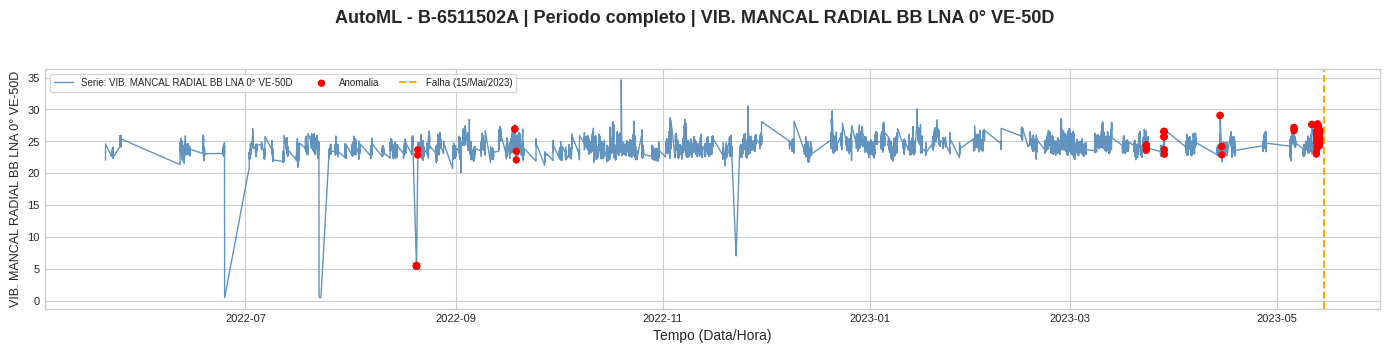

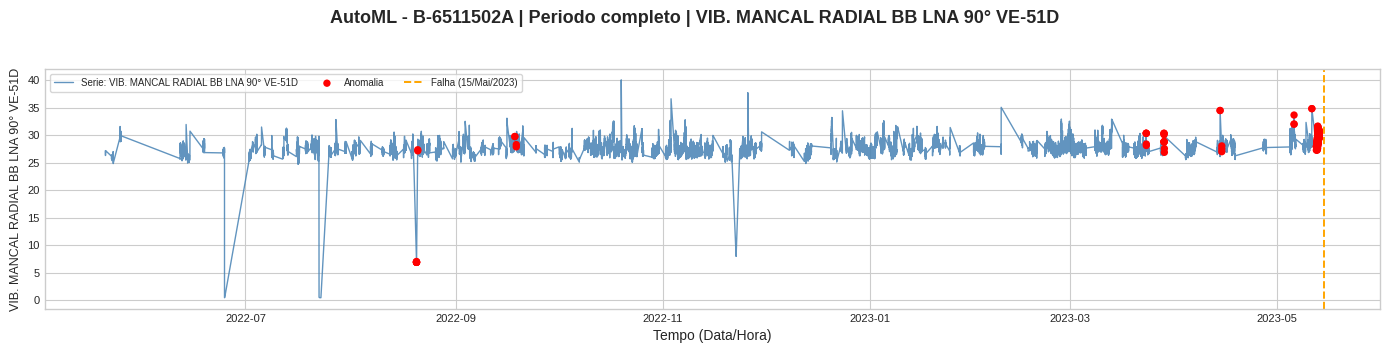

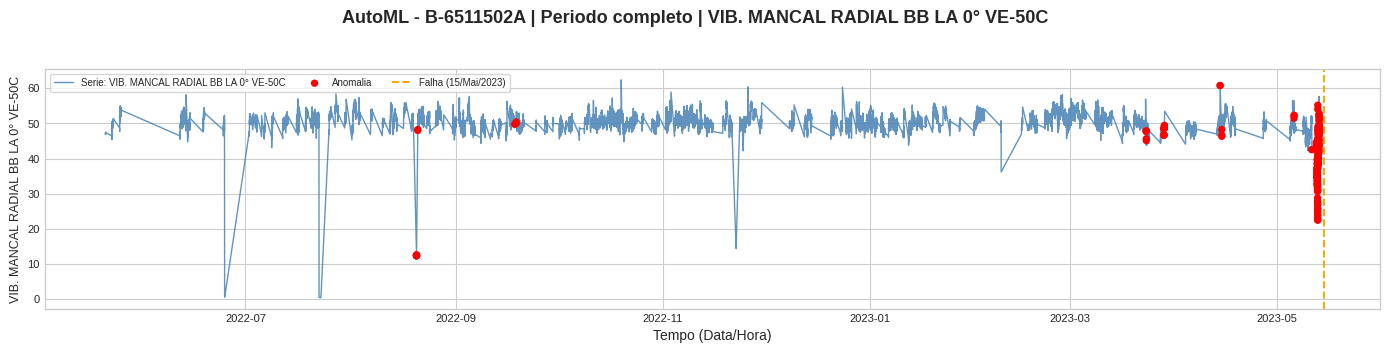

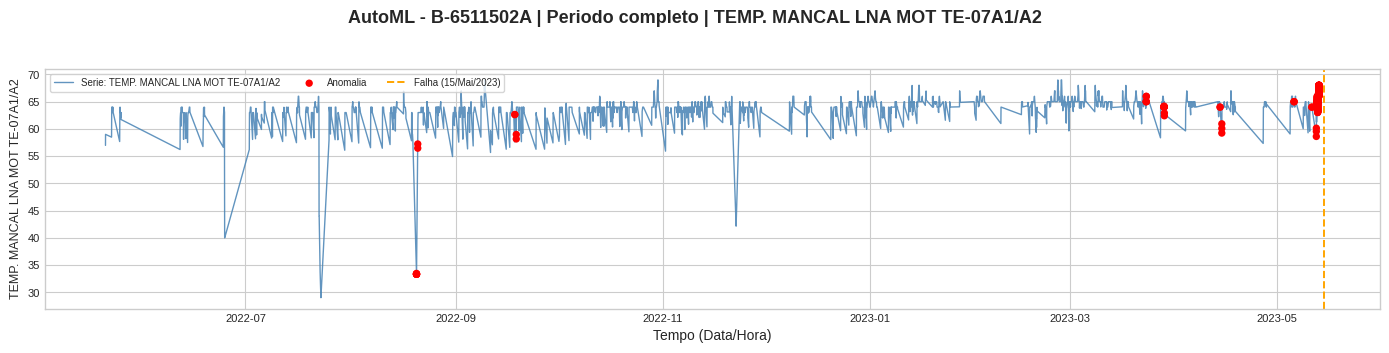

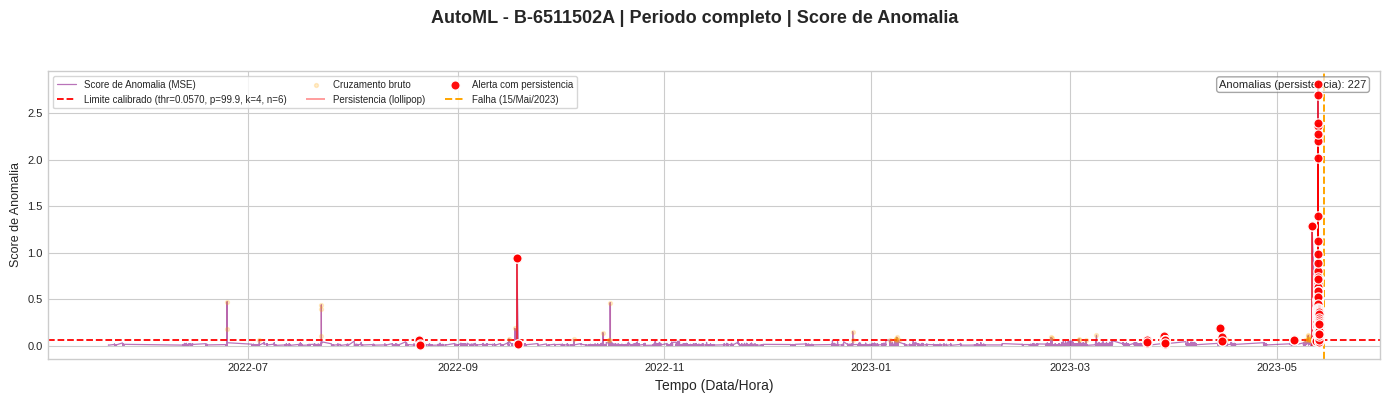

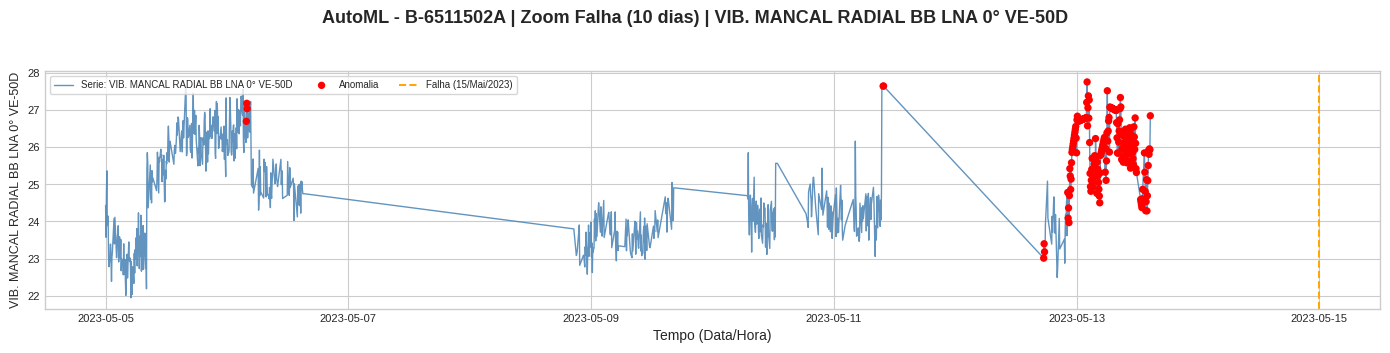

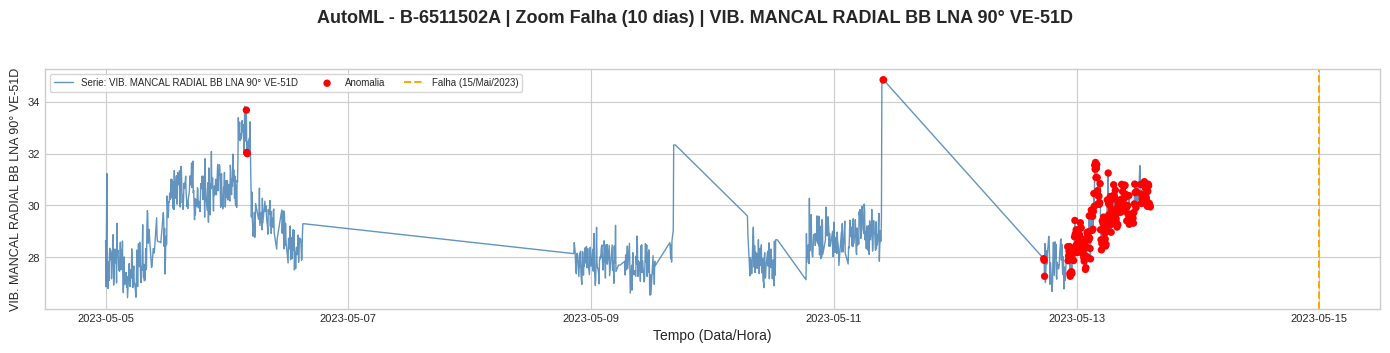

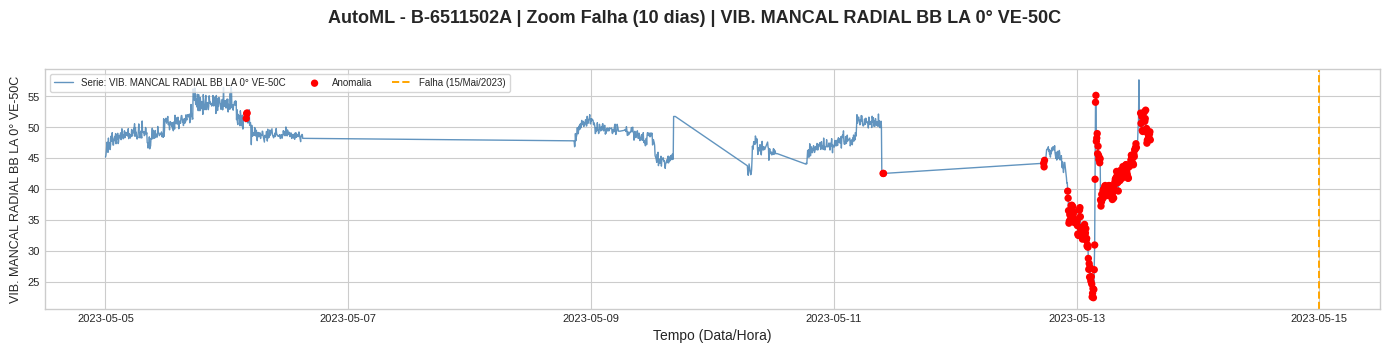

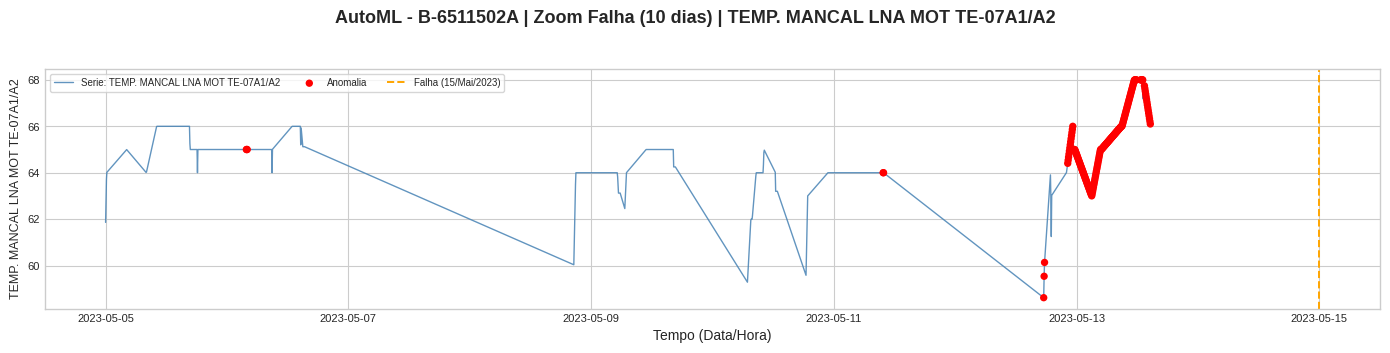

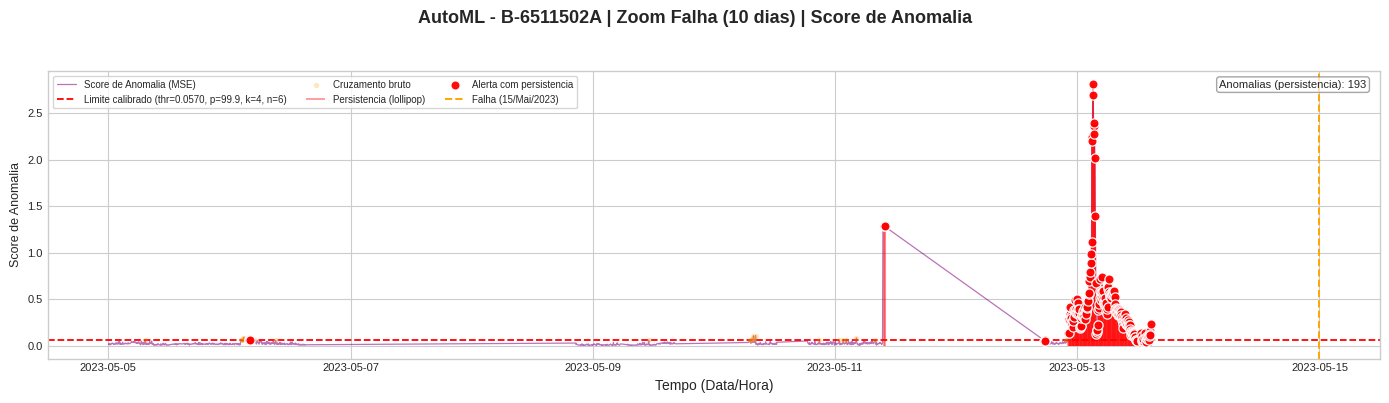

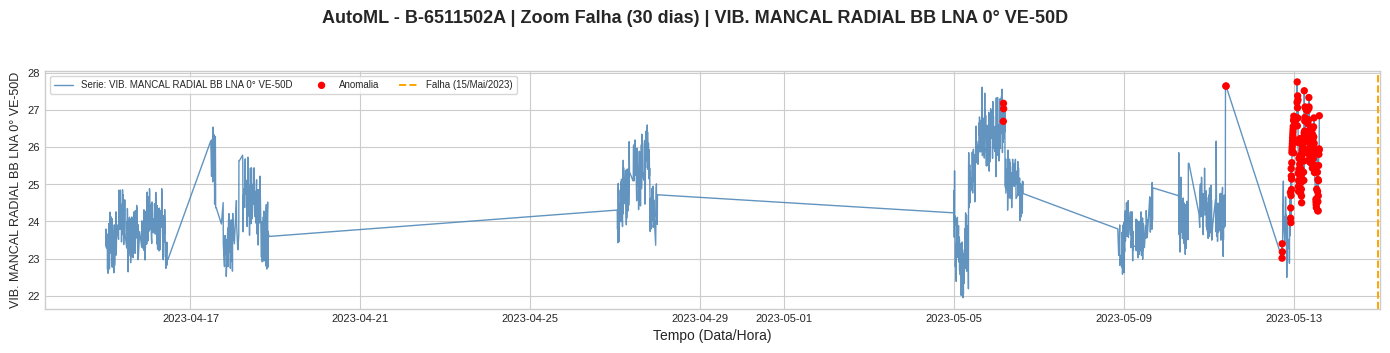

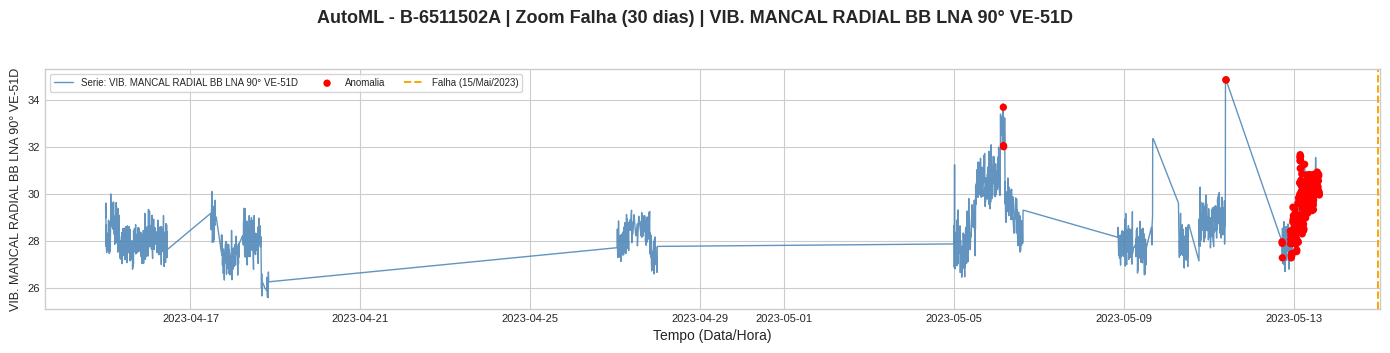

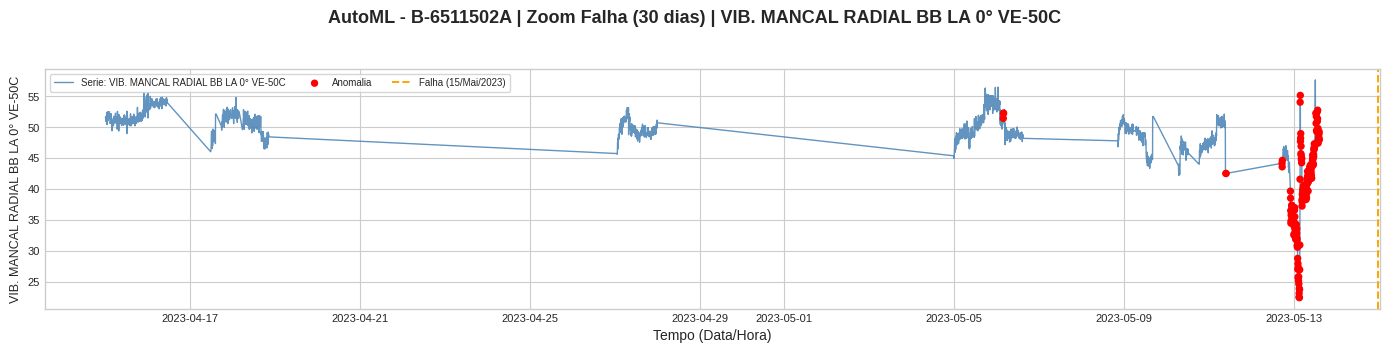

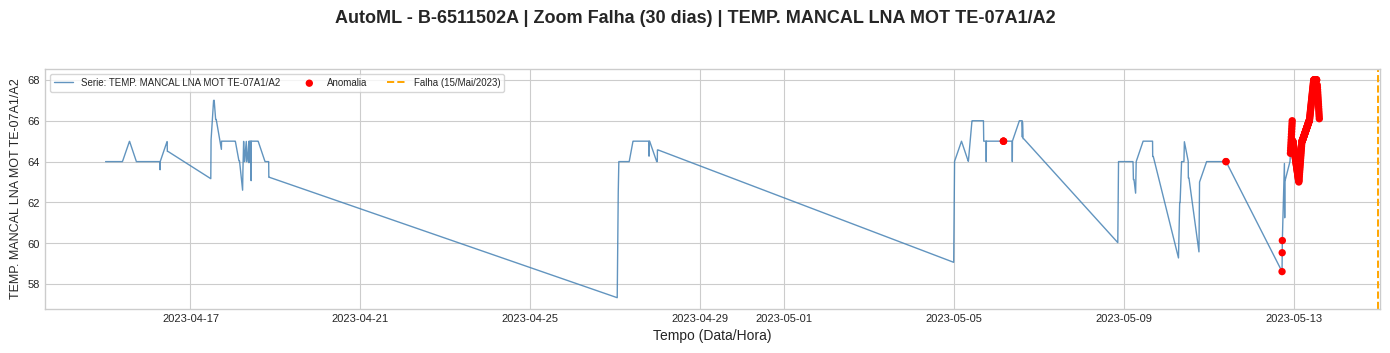

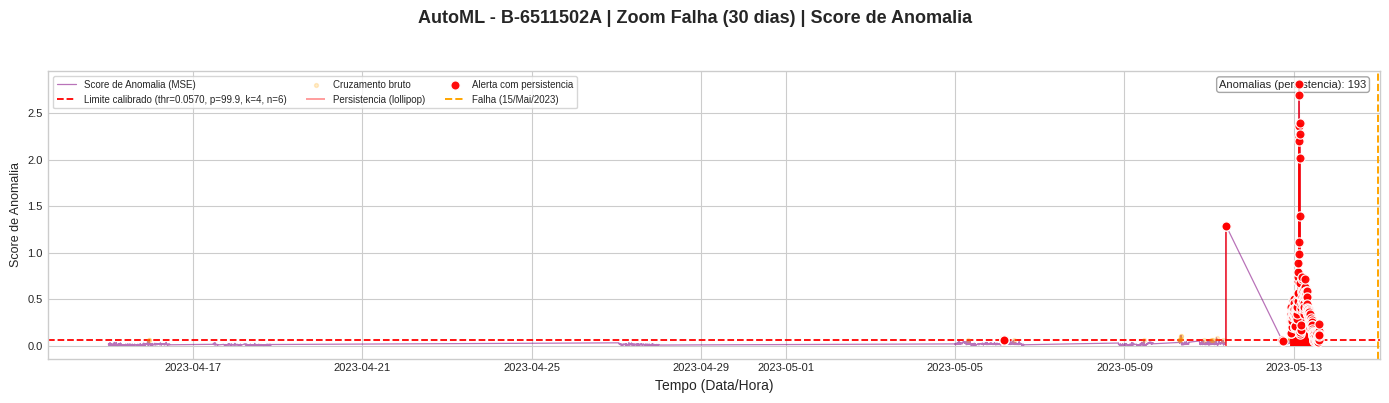


Resumo por janela:


,janela,inicio,fim,n_samples,n_anomalies,pct_anomalies,threshold,k,n
0,Periodo completo ate falha,2022-05-20 17:20:00,2023-05-15,36387,227,0.62,0.057049,4,6
1,Zoom falha (10 dias),2023-05-05 00:00:00,2023-05-15,1216,193,15.87,0.057049,4,6
2,Zoom falha (30 dias),2023-04-15 00:00:00,2023-05-15,2266,193,8.52,0.057049,4,6


In [29]:
windows = [
    {
        'name': 'Periodo completo ate falha',
        'start': scores.index.min(),
        'end': EVENT_TS_F1,
        'event_date': EVENT_DATE_F1,
        'event_label': EVENT_LABEL_F1,
        'title': f'AutoML - {EQUIPMENT_ID} | Periodo completo',
        'sensors': KEY_SENSORS,
    },
    {
        'name': 'Zoom falha (10 dias)',
        'start': EVENT_TS_F1 - pd.Timedelta(days=10),
        'end': EVENT_TS_F1,
        'event_date': EVENT_DATE_F1,
        'event_label': EVENT_LABEL_F1,
        'title': f'AutoML - {EQUIPMENT_ID} | Zoom Falha (10 dias)',
        'sensors': KEY_SENSORS,
    },
    {
        'name': 'Zoom falha (30 dias)',
        'start': EVENT_TS_F1 - pd.Timedelta(days=30),
        'end': EVENT_TS_F1,
        'event_date': EVENT_DATE_F1,
        'event_label': EVENT_LABEL_F1,
        'title': f'AutoML - {EQUIPMENT_ID} | Zoom Falha (30 dias)',
        'sensors': KEY_SENSORS,
    },
]

# --- Resumo do melhor modelo antes dos graficos ---
if trial_cfg is not None:
    model_str = str(trial_cfg.get('model', '?')).upper()
    preset_str = trial_cfg.get('preset', '?')
    cs = float(trial_res.get('composite_score') or 0)
    pre_rate = float(trial_res.get('prefailure_alert_rate') or 0)
    norm_rate = float(trial_res.get('normal_alert_rate') or 0)
    thr_pct = trial_cfg.get('threshold_percentile', '?')
    print('=' * 60)
    print(f'  MELHOR MODELO: {model_str}  |  preset: {preset_str}')
    print(f'  composite_score:   {cs:.4f}')
    print(f'  prefailure_rate:   {pre_rate:.2%}   normal_rate: {norm_rate:.2%}')
    print(f'  threshold_pct:     {thr_pct}')
    if trial_cfg.get('model') == 'lstm':
        print(f"  seq_len={trial_cfg.get('seq_len')}  hidden={trial_cfg.get('lstm_hidden_dim')}  layers={trial_cfg.get('lstm_num_layers')}")
    elif trial_cfg.get('model') == 'dense':
        print(f"  dense_layers={trial_cfg.get('dense_layers')}  lr={trial_cfg.get('learning_rate')}")
    elif trial_cfg.get('model') == 'ocsvm':
        print(f"  nu={trial_cfg.get('ocsvm_nu')}  gamma={trial_cfg.get('ocsvm_gamma')}")
    print('=' * 60)

summary_rows = []

for w in windows:
    try:
        df_window, scores_window = slice_window(df_base, scores, w['start'], w['end'])
    except ValueError as e:
        print(f"[SKIP] {w['name']}: {e}")
        continue

    threshold_flags = scores_window['reconstruction_error'] > selected_threshold
    anomaly_flags = persistence_filter(threshold_flags, k=selected_k, n=selected_n)
    n_anom = int(anomaly_flags.sum())

    event_date = pd.Timestamp(w['event_date']) if w.get('event_date') else None
    event_label = w.get('event_label') or ''

    plot_anomaly_panels(
        df_window=df_window,
        scores_window=scores_window,
        threshold_flags=threshold_flags,
        anomaly_flags=anomaly_flags,
        threshold=selected_threshold,
        threshold_label=threshold_label,
        n_anomalies=n_anom,
        event_date=event_date,
        event_label=event_label,
        title=w['title'],
        output_path=None,
        dpi=OUTPUT_DPI,
        plot_mode=PLOT_MODE,
        save_plots=SAVE_PLOTS,
        anomaly_highlight_style=ANOMALY_HIGHLIGHT_STYLE,
        key_sensors=w.get('sensors'),
    )

    n_samples = len(scores_window)
    summary_rows.append({
        'janela': w['name'],
        'inicio': pd.Timestamp(w['start']),
        'fim': pd.Timestamp(w['end']),
        'n_samples': n_samples,
        'n_anomalies': n_anom,
        'pct_anomalies': round(100.0 * n_anom / n_samples, 2) if n_samples else 0.0,
        'threshold': selected_threshold,
        'k': selected_k,
        'n': selected_n,
    })

print('\nResumo por janela:')
display(pd.DataFrame(summary_rows))

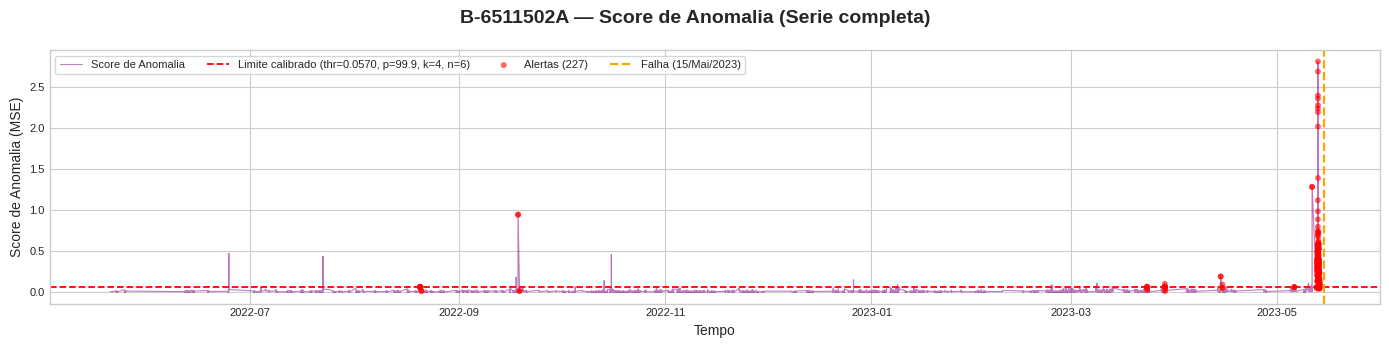

Total de alertas (serie completa): 227


In [30]:
# --- Score de anomalia completo (todos os dados) com destaque da falha ---
plt.style.use('seaborn-v0_8-whitegrid')
fig, ax = plt.subplots(figsize=(FIGSIZE_WIDTH, 3.5))

y = scores['reconstruction_error']
threshold_flags_all = y > selected_threshold
anomaly_flags_all = persistence_filter(threshold_flags_all, k=selected_k, n=selected_n)

ax.plot(scores.index, y, color='purple', linewidth=0.8, alpha=0.5, label='Score de Anomalia')
ax.axhline(selected_threshold, color='red', linestyle='--', linewidth=1.3, label=threshold_label)
ax.fill_between(scores.index, selected_threshold, y, where=(y > selected_threshold), color='red', alpha=0.08)

idx_pers = scores.index[anomaly_flags_all]
if len(idx_pers) > 0:
    ax.scatter(idx_pers, y[idx_pers], s=18, facecolor='red', edgecolor='none', alpha=0.6, zorder=4, label=f'Alertas ({len(idx_pers)})')

ax.axvline(EVENT_TS_F1, color='orange', linestyle='--', linewidth=1.6, label=EVENT_LABEL_F1)

ax.set_ylabel('Score de Anomalia (MSE)', fontsize=10)
ax.set_xlabel('Tempo', fontsize=10)
ax.tick_params(axis='both', labelsize=8)
ax.legend(loc='upper left', fontsize=8, ncol=4, frameon=True)
fig.suptitle(f'{EQUIPMENT_ID} — Score de Anomalia (Serie completa)', fontsize=14, fontweight='bold')
fig.tight_layout()
plt.show()

print(f'Total de alertas (serie completa): {int(anomaly_flags_all.sum())}')